# Import Important Libraries:

In [2]:
import  pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, MaxPooling2D, Conv2D, Dropout, Flatten

# Import the data or Download it:

In [1]:
# Install Dataset Library in Colab
# AS EMNIST is not included in Keras.
!pip install emnist

In [16]:
!pip install -q tensorflow-datasets

In [17]:
import tensorflow_datasets as tfds

ds_train = tfds.load(
    "emnist/letters",
    split="train",
    as_supervised=True
)

ds_test = tfds.load(
    "emnist/letters",
    split="test",
    as_supervised=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.QYMRUQ_3.1.0/emnist-train.tfrecord-[0-9][0-9][0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.QYMRUQ_3.1.0/emnist-test.tfrecord-[0-9][0-9][0-9…

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.


# Convert data into usable numpy arrays:


In [18]:
import numpy as np

X_train = []
y_train = []

for image, label in tfds.as_numpy(ds_train):
    X_train.append(image)
    y_train.append(label)

X_train = np.array(X_train)
y_train = np.array(y_train)

print(X_train.shape)
print(y_train.shape)

(88800, 28, 28, 1)
(88800,)


In [22]:

# Test Data
X_test = []
y_test = []

for image, label in tfds.as_numpy(ds_test):
    X_test.append(image)
    y_test.append(label)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (88800, 28, 28, 1) (88800,)
Test : (14800, 28, 28, 1) (14800,)


In [23]:
y_train = y_train - 1
y_test = y_test - 1

# Let's observe our data:

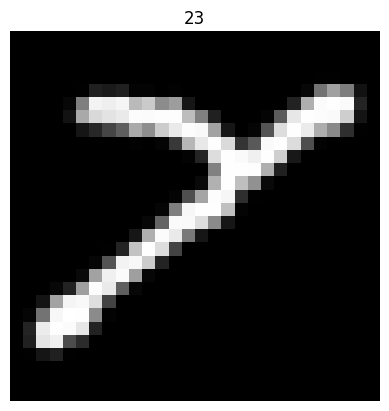

In [24]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0:4].squeeze(), cmap="gray")
plt.title(y_train[0:4])
plt.axis("off")
plt.show()

# EMNIST Images are rotated and fixed so we will fix it:

In [27]:
X_train = np.transpose(
    X_train,
    axes=(0, 2, 1, 3)
)

X_test = np.transpose(
    X_test,
    axes=(0, 2, 1, 3)
)

X_train = np.flip(
    X_train,
    axis=2
)

X_test = np.flip(
    X_test,
    axis=2
)

# Preprocess the Images:

In [28]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1,28,28,1)

X_test = X_test.reshape(-1,28,28,1)


# Building the model:

In [29]:
def my_model():
  model = Sequential([
      Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
      MaxPooling2D((2,2)),
      Conv2D(64,(3,3),activation='relu'),
      MaxPooling2D((2,2)),
      Flatten(),
      Dense(128,activation='relu'),
      Dropout(0.3),
      Dense(26,activation='softmax'),
  ])

  return model
model  = my_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,098 (887.10 KB)

 Trainable params: 227,098 (887.10 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [32]:
# We will use early stopping to save computation and achieve best reults:
from tensorflow.keras.callbacks import EarlyStopping
cbks = EarlyStopping(
    monitor ='val_loss',
    patience = 3,
    restore_best_weights = True,
    verbose=1,
)

In [36]:
# Ensure labels are strictly in the [0, 25] range
y_train = np.clip(y_train, 0, 25)
y_test = np.clip(y_test, 0, 25)

# Re-initialize and compile the model
model = my_model()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, validation_split=0.2, epochs=20, callbacks=cbks, batch_size=64)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 82s 72ms/step - accuracy: 0.7604 - loss: 0.7679 - val_accuracy: 0.8866 - val_loss: 0.3343
Epoch 2/20
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 84s 74ms/step - accuracy: 0.8759 - loss: 0.3849 - val_accuracy: 0.9082 - val_loss: 0.2730
Epoch 3/20
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 174s 103ms/step - accuracy: 0.8966 - loss: 0.3168 - val_accuracy: 0.9212 - val_loss: 0.2444
Epoch 4/20
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 112s 76ms/step - accuracy: 0.9074 - loss: 0.2772 - val_accuracy: 0.9243 - val_loss: 0.2351
Epoch 5/20
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 85s 77ms/step - accuracy: 0.9178 - loss: 0.2433 - val_accuracy: 0.9273 - val_loss: 0.2279
Epoch 6/20
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 92s 83ms/step - accuracy: 0.9229 - loss: 0.2205 - val_accuracy: 0.9300 - val_loss: 0.2184
Epoch 7/20
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 78s 70ms/step - accuracy: 0.9299 - loss: 0.2046 - val_accuracy: 0.9327 - val_loss: 0.2190
Epoch 8/20
1110/1110 ━━━━━━━━━━━━━━━━━━━━ 71s 61ms/step - accuracy: 0.932

In [ ]:
# Load the trained model to fix the 5% accuracy issue caused by variable reset
try:
    model = keras.models.load_model('emnist_cnn.keras')
    print('Trained model successfully loaded!')
    # Re-run prediction
    y_pred = model.predict(X_test).argmax(axis=1)
except Exception as e:
    print(f'Error loading model: {e}. Please ensure you ran the training cell completely.')

# Evaluate on test data:

In [37]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

463/463 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.0539 - loss: 15.8198
Test Loss: 15.8198
Test Accuracy: 0.0539


# Make Predictions:

In [38]:
y_pred_probs = model.predict(X_test)

y_pred = y_pred_probs.argmax(axis=1)

463/463 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step


In [39]:
letters = [
    chr(i)
    for i in range(65,91)
]

# Visualize Predictions:

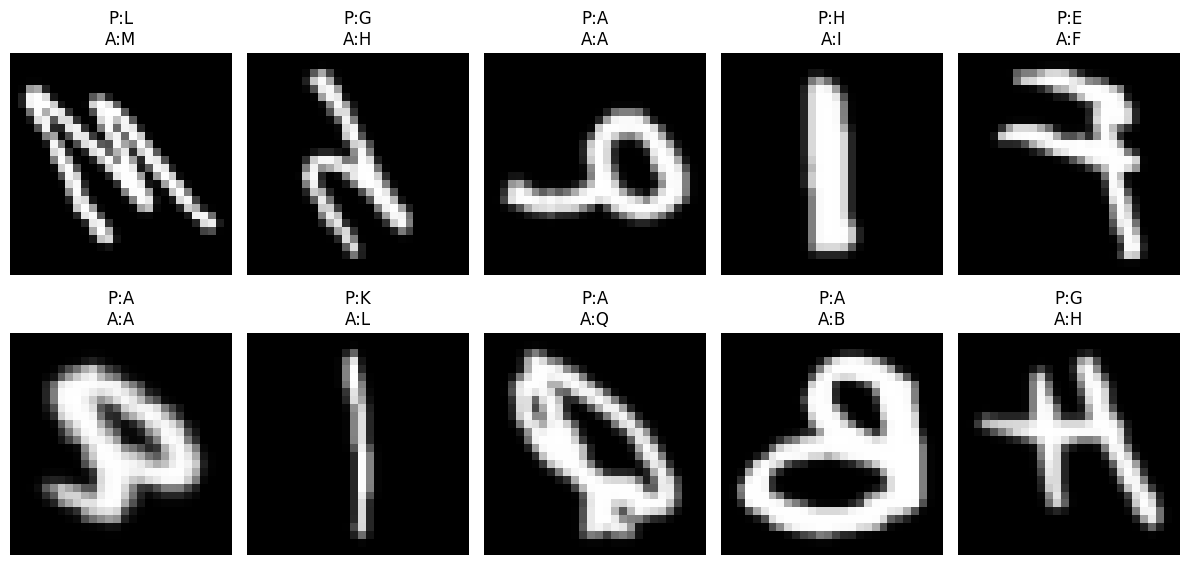

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(
        X_test[i].squeeze(),
        cmap='gray'
    )

    plt.title(
        f"P:{letters[y_pred[i]]}\nA:{letters[y_test[i]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

# Building a Confusion Matrix:

In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[762   2   3   2   1   6   2   0   0   1   0   0   0   3   0  12   2   0
    0   1   0   0   0   0   3]
 [771   0   1   1   0   8   5   2   0   1   1   0   1   3   0   0   3   0
    0   0   0   0   0   0   3]
 [  1 763   0  23   0   2   0   0   0   0   3   0   0   1   0   0   1   2
    0   3   0   0   0   0   1]
 [ 11   1 742   0   0   0   1   0   1   0   0   0   1  34   4   4   0   0
    1   0   0   0   0   0   0]
 [  9   4   0 774   3   1   0   1   0   2   1   0   0   0   2   0   1   1
    0   0   0   0   0   0   1]
 [  0   0   0   4 765   6   0   0   0   0   1   0   0   0   6   0   1   3
   11   0   0   0   0   2   1]
 [ 23   2   1   2   3 672   0   0   3   0   0   0   1   0   0  83   0   5
    0   1   0   0   0   4   0]
 [ 14   0   0   0   0   0 741   0   0  17   3   4  10   0   0   1   1   0
    1   4   0   0   4   0   0]
 [  2   1   0   1   1   1   1 600  15   0 168   0   0   0   0   0   0   0
    0   0   2   0   2   0   6]
 [  3   0   3   0   3   7   0  13 755   0   2   0   0  

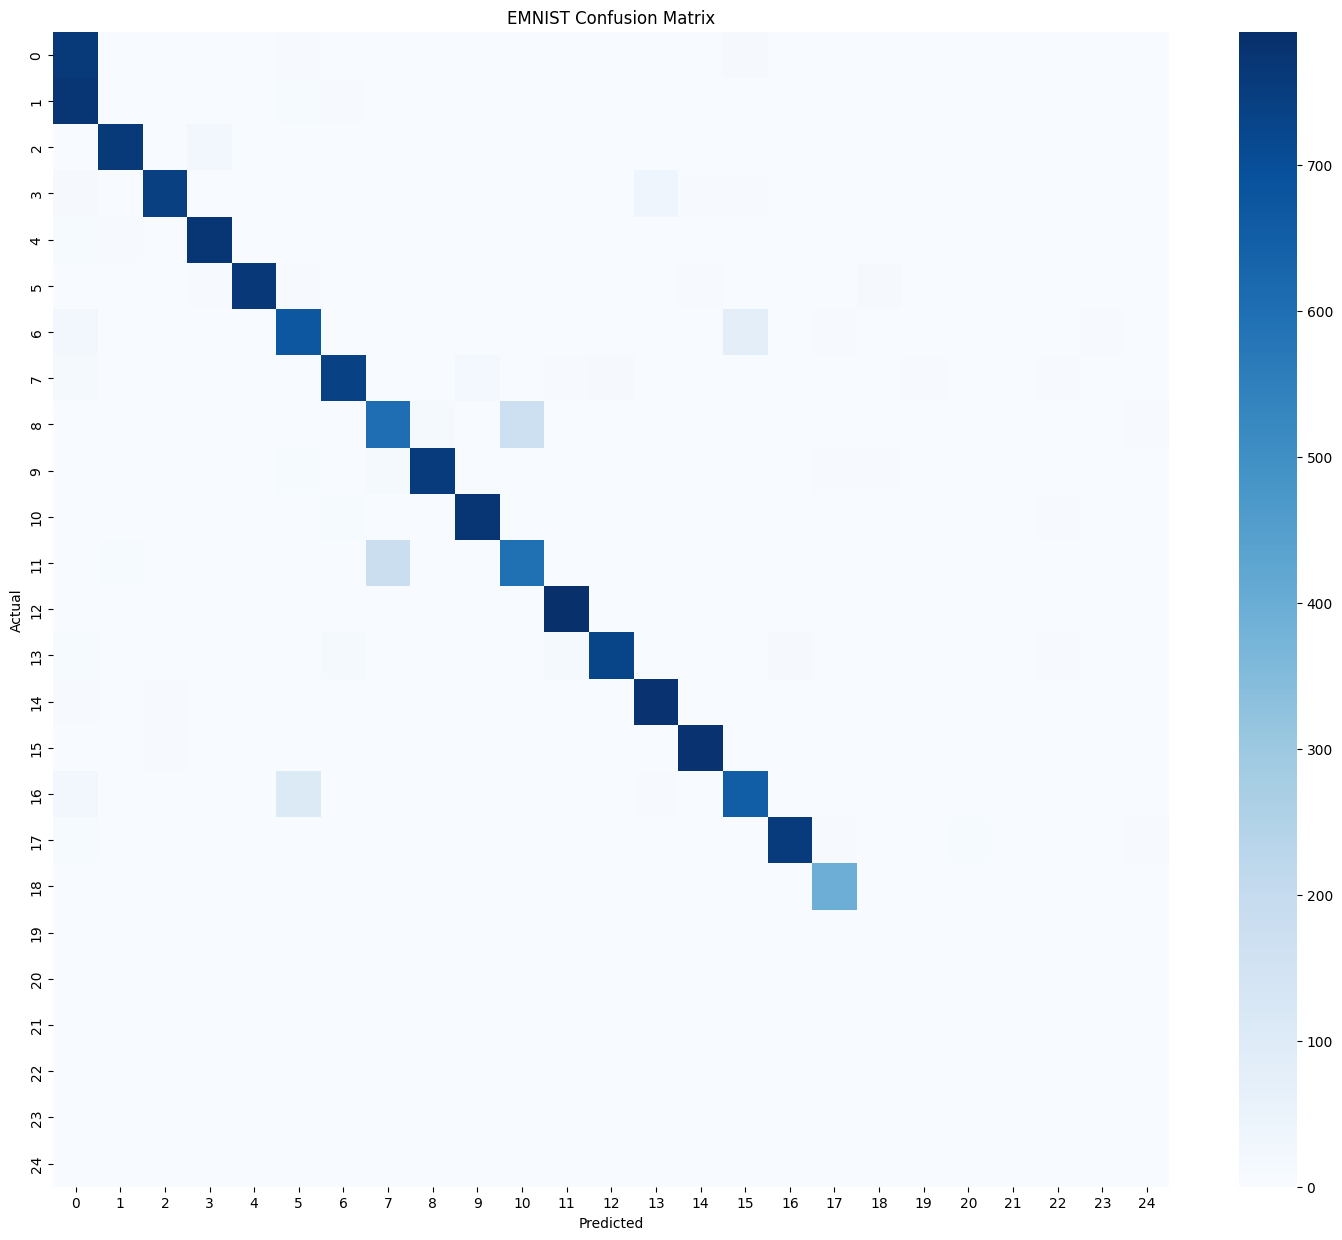

In [42]:
import seaborn as sns

plt.figure(figsize=(18,15))

sns.heatmap(
    cm,
    cmap='Blues'
)

plt.title(
    "EMNIST Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Benchmarks Testing:

In [50]:
from sklearn.metrics import classification_report

# Get the unique classes actually present in the predictions/test set
unique_labels = np.unique(np.concatenate([y_test, y_pred]))
current_target_names = [letters[i] for i in unique_labels]

print(
    classification_report(
        y_test,
        y_pred,
        labels=unique_labels,
        target_names=current_target_names
    )
)

              precision    recall  f1-score   support

           A       0.46      0.95      0.62       800
           B       0.00      0.00      0.00       800
           C       0.00      0.00      0.00       800
           D       0.00      0.00      0.00       800
           E       0.00      0.00      0.00       800
           F       0.01      0.01      0.01       800
           G       0.00      0.00      0.00       800
           H       0.00      0.00      0.00       800
           I       0.02      0.02      0.02       800
           J       0.00      0.00      0.00       800
           K       0.00      0.00      0.00       800
           L       0.00      0.00      0.00       800
           M       0.00      0.00      0.00       800
           N       0.00      0.00      0.00       800
           O       0.00      0.00      0.00       800
           P       0.00      0.00      0.00       800
           Q       0.00      0.00      0.00       800
           R       0.01    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Check for Errors:

In [44]:
wrong = np.where(
    y_pred != y_test
)[0]

print(
    "Wrong Predictions:",
    len(wrong)
)

Wrong Predictions: 14002


# Display  Mistakes:

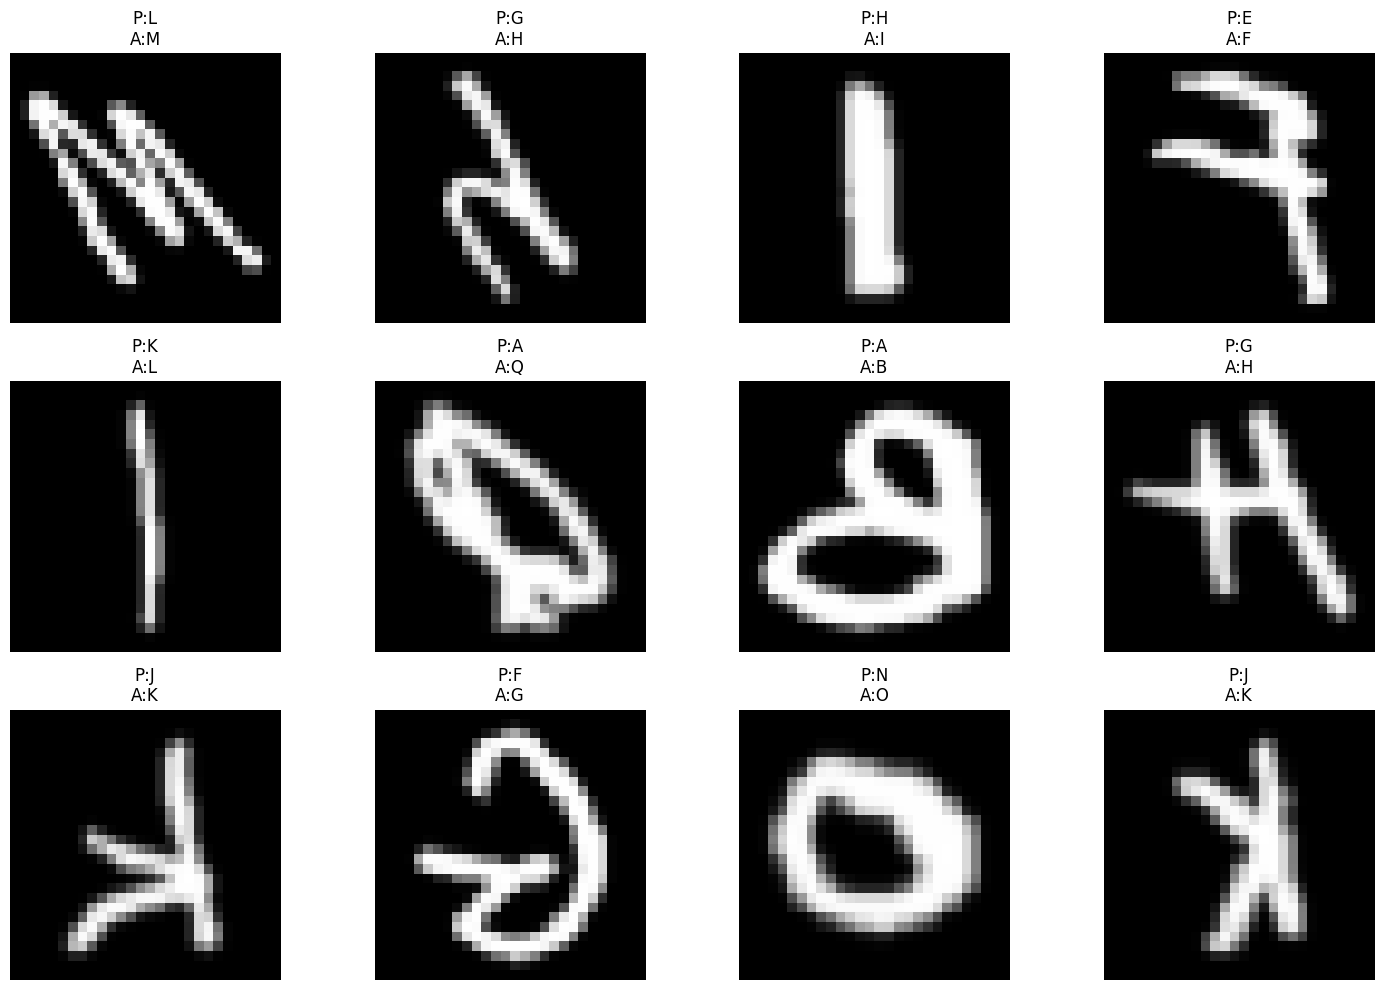

In [45]:
plt.figure(figsize=(15,10))

for i in range(12):

    idx = wrong[i]

    plt.subplot(3,4,i+1)

    plt.imshow(
        X_test[idx].squeeze(),
        cmap='gray'
    )

    plt.title(
        f"P:{letters[y_pred[idx]]}\nA:{letters[y_test[idx]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

# Save and Download the model:

In [49]:
model.save("emnist_cnn.keras")

from google.colab import files

files.download(
    "emnist_cnn.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>